# NBA Player PER Predictor
**Regression: predict next season's Player Efficiency Rating (PER)**



In [1]:
from nba_api.stats.endpoints import leaguedashplayerstats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Pull stats for two seasons
df_train_raw = leaguedashplayerstats.LeagueDashPlayerStats(season='2022-23').get_data_frames()[0]
df_test_raw  = leaguedashplayerstats.LeagueDashPlayerStats(season='2023-24').get_data_frames()[0]

print('2022-23:', df_train_raw.shape)
print('2023-24:', df_test_raw.shape)
df_train_raw.head(3)

2022-23: (539, 67)
2023-24: (572, 67)


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,1630639,A.J. Lawson,A.J.,1610612742,DAL,22.0,15,5,10,0.333,...,96,74,457,437,369,466,253,39,461,2
1,1631260,AJ Green,AJ,1610612749,MIL,23.0,35,27,8,0.771,...,42,132,471,383,327,406,253,39,401,1
2,1631100,AJ Griffin,AJ,1610612737,ATL,19.0,72,34,38,0.472,...,336,272,318,185,127,230,253,39,219,1


In [3]:
def compute_per_proxy(df):
    """Simplified PER proxy from counting stats per minute."""
    df = df.copy()
    df['MIN'] = pd.to_numeric(df['MIN'], errors='coerce')
    df = df[df['MIN'] > 500].copy()   # At least ~6 min/game over full season
    mp = df['MIN']
    df['per_proxy'] = (
        df['PTS'] + df['REB'] + df['AST'] + df['STL'] + df['BLK'] - df['TOV']
    ) / mp * 36
    return df

df_s1 = compute_per_proxy(df_train_raw)
df_s2 = compute_per_proxy(df_test_raw)

print('Players retained — 2022-23:', len(df_s1), '| 2023-24:', len(df_s2))

Players retained — 2022-23: 367 | 2023-24: 360


In [4]:
# Join next season's PER proxy as the target
next_per = df_s2[['PLAYER_NAME', 'per_proxy']].rename(columns={'per_proxy': 'next_per'})
df = df_s1.merge(next_per, on='PLAYER_NAME', how='inner')

print('Players in both seasons (train set):', len(df))
df[['PLAYER_NAME', 'per_proxy', 'next_per', 'MIN', 'PTS', 'REB', 'AST']].head()

Players in both seasons (train set): 293


,PLAYER_NAME,per_proxy,next_per,MIN,PTS,REB,AST
0,Aaron Gordon,30.918103,27.256935,2055.106667,1109,446,203
1,Aaron Holiday,18.015830,21.895590,845.256667,247,74,89
2,Aaron Nesmith,22.336449,23.643186,1816.403333,738,277,98
3,Aaron Wiggins,21.309711,24.421422,1297.436667,479,211,80
4,Al Horford,23.401991,24.727027,1921.375000,616,390,189


In [5]:
features = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV',
            'FG_PCT', 'FG3_PCT', 'FT_PCT', 'MIN', 'per_proxy']

df_clean = df.dropna(subset=features + ['next_per']).copy()

X = df_clean[features]
y = df_clean['next_per']

print(f'Samples: {len(X)} | Features: {len(features)}')
print(f"next_per range: {y.min():.1f} – {y.max():.1f} | mean: {y.mean():.1f}")

Samples: 293 | Features: 11
next_per range: 16.0 – 54.0 | mean: 27.1


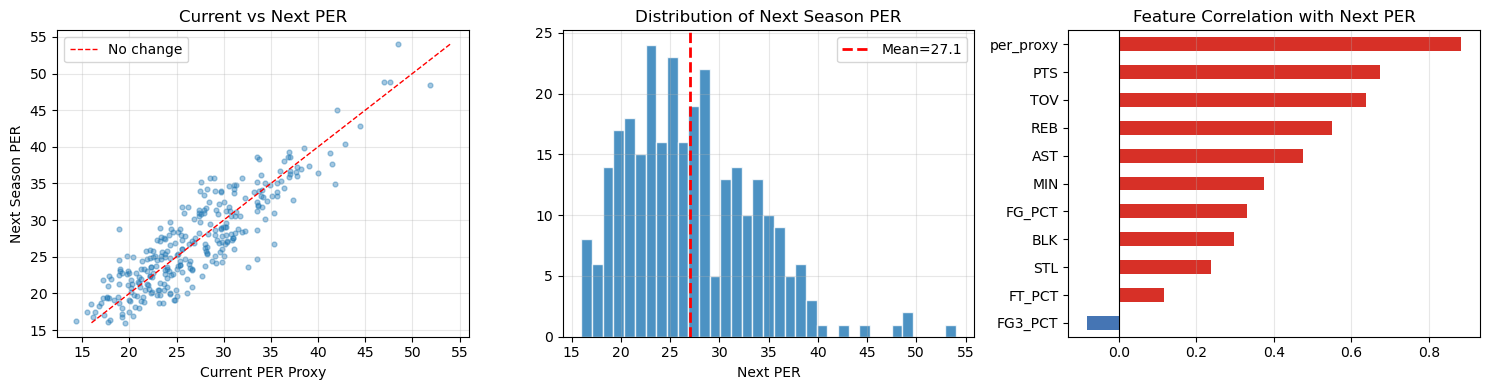

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Current vs next PER
axes[0].scatter(df_clean['per_proxy'], y, alpha=0.4, s=12)
mn, mx = y.min(), y.max()
axes[0].plot([mn,mx],[mn,mx],'r--', lw=1, label='No change')
axes[0].set_xlabel('Current PER Proxy'); axes[0].set_ylabel('Next Season PER')
axes[0].set_title('Current vs Next PER'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Distribution of next_per
axes[1].hist(y, bins=35, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[1].axvline(y.mean(), color='red', linestyle='--', lw=2, label=f'Mean={y.mean():.1f}')
axes[1].set_title('Distribution of Next Season PER')
axes[1].set_xlabel('Next PER'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Correlation with next_per
corrs = df_clean[features + ['next_per']].corr()['next_per'].drop('next_per').sort_values()
corrs.plot(kind='barh', ax=axes[2], color=['#d73027' if c > 0 else '#4575b4' for c in corrs])
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('Feature Correlation with Next PER'); axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda.png', dpi=150)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_clean.index, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_sc, y_train)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 234 | Test: 59


In [8]:
y_pred = model.predict(X_test_sc)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  (avg error in PER points): {mae:.2f}')
print(f'RMSE (penalizes big errors):    {rmse:.2f}')
print(f'R²   (variance explained):      {r2:.3f}')

MAE  (avg error in PER points): 2.88
RMSE (penalizes big errors):    3.53
R²   (variance explained):      0.708


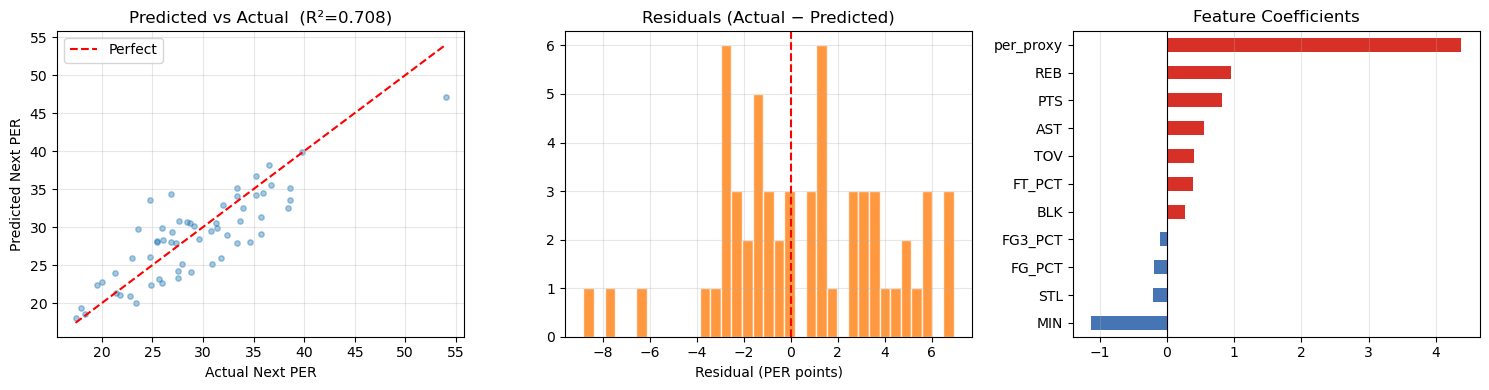

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn,mx],[mn,mx],'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Actual Next PER'); axes[0].set_ylabel('Predicted Next PER')
axes[0].set_title(f'Predicted vs Actual  (R²={r2:.3f})')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=35, color='#ff7f0e', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Residuals (Actual − Predicted)')
axes[1].set_xlabel('Residual (PER points)'); axes[1].grid(alpha=0.3)

# Feature coefficients
coefs = pd.Series(model.coef_, index=features).sort_values()
coefs.plot(kind='barh', ax=axes[2],
           color=['#d73027' if c > 0 else '#4575b4' for c in coefs])
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('Feature Coefficients')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150)
plt.show()

In [10]:
errors = df_clean.loc[idx_test, ['PLAYER_NAME']].copy()
errors['actual']    = y_test.values
errors['predicted'] = y_pred
errors['residual']  = errors['actual'] - errors['predicted']
errors['abs_error'] = errors['residual'].abs()
errors['type']      = np.where(errors['residual'] > 0, 'Under-predicted', 'Over-predicted')

worst5 = errors.sort_values('abs_error', ascending=False).head(5)
worst5

,PLAYER_NAME,actual,predicted,residual,abs_error,type
159,Jrue Holiday,24.749939,33.563333,-8.813395,8.813395,Over-predicted
45,Christian Wood,26.795319,34.387960,-7.592641,7.592641,Over-predicted
143,Joel Embiid,53.998419,47.072304,6.926115,6.926115,Under-predicted
176,Kevin Love,35.756044,29.092498,6.663545,6.663545,Under-predicted
59,Day'Ron Sharpe,34.687016,28.076232,6.610784,6.610784,Under-predicted


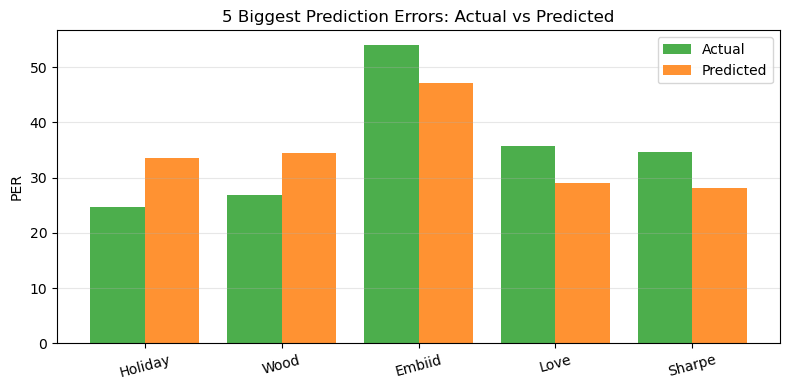

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

names = worst5['PLAYER_NAME'].str.split().str[-1]
x = np.arange(len(worst5))

ax.bar(x - 0.2, worst5['actual'],    0.4, label='Actual',    color='#2ca02c', alpha=0.85)
ax.bar(x + 0.2, worst5['predicted'], 0.4, label='Predicted', color='#ff7f0e', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel('PER')
ax.set_title('5 Biggest Prediction Errors: Actual vs Predicted')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150)
plt.show()

In [12]:
top3 = pd.Series(model.coef_, index=features).abs().sort_values(ascending=False).head(3)

print('=' * 45)
print('  NBA PER REGRESSION — RESULTS')
print('=' * 45)
print(f'  MAE  : {mae:.2f} PER points')
print(f'  RMSE : {rmse:.2f} PER points')
print(f'  R²   : {r2:.3f}')
print('-' * 45)
print('  Top 3 predictors:')
for feat, val in top3.items():
    print(f'    • {feat}: {val:.3f}')
print('=' * 45)

  NBA PER REGRESSION — RESULTS
  MAE  : 2.88 PER points
  RMSE : 3.53 PER points
  R²   : 0.708
---------------------------------------------
  Top 3 predictors:
    • per_proxy: 4.379
    • MIN: 1.123
    • REB: 0.954
